# Griffiths QM
## Chapter 5: Identical Particles — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--|:--|
| [5.5](#prob_5_5)   | Exchange Force — Bosons vs Fermions |
| [5.9](#prob_5_9)   | Free Electron Gas — Fermi Energy |
| [5.11](#prob_5_11) | Free Electron Gas — Density of States |
| [5.12](#prob_5_12) | Band Theory — Dirac Comb |
| [5.15](#prob_5_15) | Planck Distribution — Blackbody Radiation |
| [5.16](#prob_5_16) | Bose-Einstein Condensation |
| [5.20](#prob_5_20) | Sommerfeld Expansion — Heat Capacity |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 5.5 — Exchange Force: Bosons vs Fermions {#prob_5_5}

$\langle(x_1-x_2)^2\rangle_\pm = D \mp 2|\langle x\rangle_{ab}|^2$,
where $D$ is the distinguishable result.


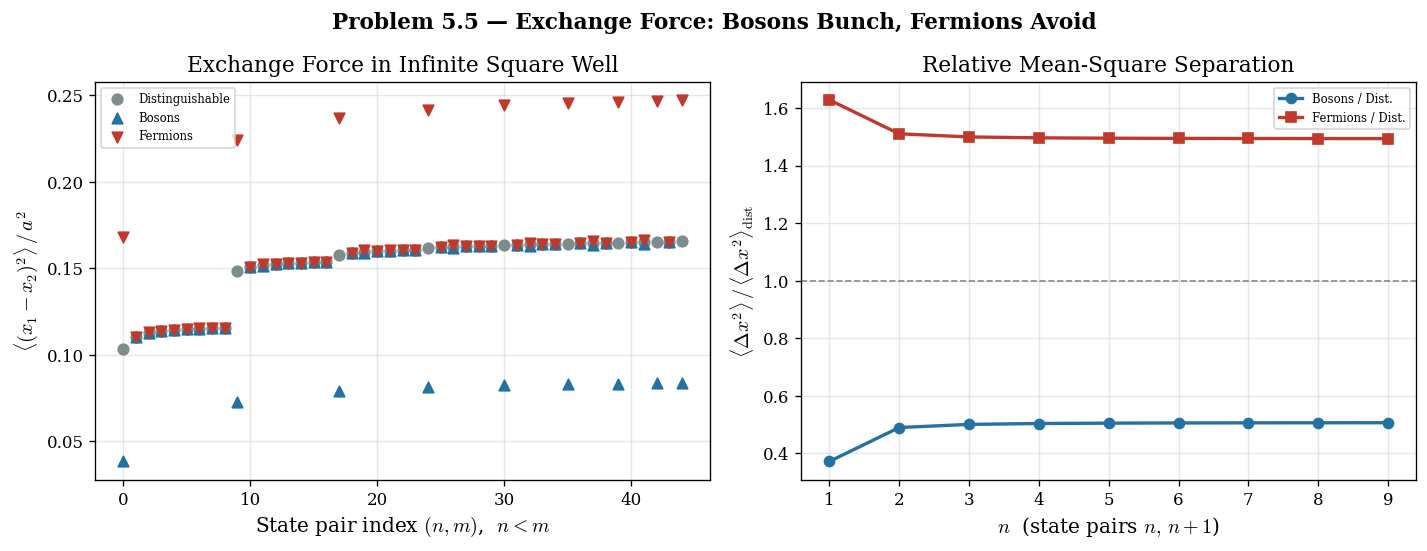

In [2]:
# Figure 5.5: Exchange force in infinite square well
a = 1.0

def x_expect(n, a=1.0):
    return a / 2.0

def x2_expect(n, a=1.0):
    return a**2 * (1/3 - 1/(2*n**2 * np.pi**2))

def x_cross(n, m, a=1.0):
    val, _ = quad(lambda x: (2/a)*np.sin(n*np.pi*x/a)*x*np.sin(m*np.pi*x/a), 0, a)
    return val

n_max = 10
D_vals, bose_vals, fermi_vals = [], [], []
for n in range(1, n_max+1):
    for m in range(1, n_max+1):
        if m <= n:
            continue
        xn2 = x2_expect(n); xm2 = x2_expect(m)
        xn  = x_expect(n);  xm  = x_expect(m)
        xc  = x_cross(n, m)
        D   = xn2 + xm2 - 2*xn*xm
        ex  = 2 * xc**2
        D_vals.append(D)
        bose_vals.append(D - ex)
        fermi_vals.append(D + ex)

D_vals = np.array(D_vals)
bose_vals = np.array(bose_vals)
fermi_vals = np.array(fermi_vals)
pair_idx = np.arange(len(D_vals))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(pair_idx, D_vals,     color=GRAY, s=40, label='Distinguishable', zorder=3)
ax.scatter(pair_idx, bose_vals,  color=BLUE, s=40, marker='^', label='Bosons', zorder=3)
ax.scatter(pair_idx, fermi_vals, color=RED,  s=40, marker='v', label='Fermions', zorder=3)
ax.set_xlabel(r'State pair index $(n,m)$,  $n<m$')
ax.set_ylabel(r'$\langle(x_1-x_2)^2\rangle\,/\,a^2$')
ax.set_title('Exchange Force in Infinite Square Well')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ns = np.arange(1, 10)
ratios_b, ratios_f = [], []
for n in ns:
    m  = n + 1
    D  = x2_expect(n) + x2_expect(m) - 2*x_expect(n)*x_expect(m)
    ex = 2 * x_cross(n, m)**2
    ratios_b.append((D - ex)/D)
    ratios_f.append((D + ex)/D)

ax2.plot(ns, ratios_b, color=BLUE, lw=2, marker='o', label='Bosons / Dist.')
ax2.plot(ns, ratios_f, color=RED,  lw=2, marker='s', label='Fermions / Dist.')
ax2.axhline(1.0, color=GRAY, ls='--', lw=1)
ax2.set_xlabel(r'$n$  (state pairs $n,\,n+1$)')
ax2.set_ylabel(r'$\langle\Delta x^2\rangle\,/\,\langle\Delta x^2\rangle_{\rm dist}$')
ax2.set_title('Relative Mean-Square Separation')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 5.5 — Exchange Force: Bosons Bunch, Fermions Avoid',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_5.png')); plt.show()


---
## Problem 5.9 & 5.11 — Free Electron Gas: Fermi Energy & DOS {#prob_5_9}

$E_F = \frac{\hbar^2}{2m}(3\pi^2\rho)^{2/3}$,  $g(E) = \frac{3N}{2E_F}\sqrt{E/E_F}$


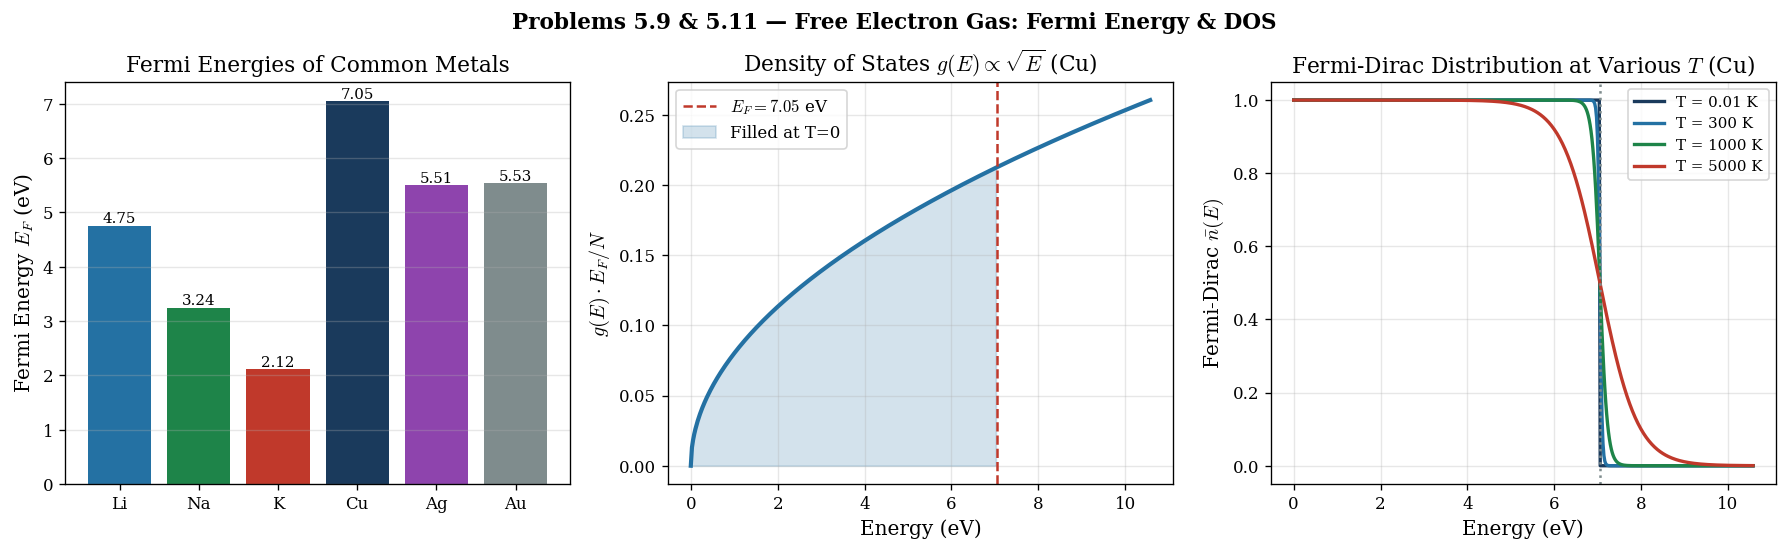

Fermi energies (eV):
  Li: 4.75 eV
  Na: 3.24 eV
  K: 2.12 eV
  Cu: 7.05 eV
  Ag: 5.51 eV
  Au: 5.53 eV


In [3]:
# Figure 5.9/5.11: Fermi energy, DOS, Fermi-Dirac distribution
hbar = 1.055e-34; m_e = 9.109e-31; eV = 1.602e-19

metals = {'Li':4.70e28,'Na':2.65e28,'K':1.40e28,'Cu':8.49e28,'Ag':5.86e28,'Au':5.90e28}
EF_eV  = {name: (hbar**2/(2*m_e))*(3*np.pi**2*rho)**(2/3)/eV
           for name, rho in metals.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: Fermi energies bar chart
ax = axes[0]
names = list(EF_eV.keys()); EFs = list(EF_eV.values())
bars = ax.bar(names, EFs, color=[BLUE,GREEN,RED,NAVY,PURP,GRAY])
ax.set_ylabel(r'Fermi Energy $E_F$ (eV)')
ax.set_title('Fermi Energies of Common Metals')
for b, v in zip(bars, EFs):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Middle: DOS g(E) for Cu
ax2   = axes[1]
EF_Cu = EF_eV['Cu']
E_arr = np.linspace(0, 1.5*EF_Cu, 400)
g_E   = (3/(2*EF_Cu)) * np.sqrt(E_arr/EF_Cu)
ax2.plot(E_arr, g_E, color=BLUE, lw=2.5)
ax2.axvline(EF_Cu, color=RED, ls='--', lw=1.5, label=fr'$E_F = {EF_Cu:.2f}$ eV')
ax2.fill_between(E_arr, g_E, where=E_arr<=EF_Cu, alpha=0.2, color=BLUE, label='Filled at T=0')
ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel(r'$g(E)\cdot E_F/N$')
ax2.set_title(r'Density of States $g(E)\propto\sqrt{E}$ (Cu)')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Right: Fermi-Dirac at several T
ax3 = axes[2]
E_fd = np.linspace(0, 1.5*EF_Cu, 500)
kB   = 8.617e-5  # eV/K
T_vals   = [0.01, 300, 1000, 5000]
colors_T = [NAVY, BLUE, GREEN, RED]
for T, c in zip(T_vals, colors_T):
    if T < 1:
        fd = np.where(E_fd < EF_Cu, 1.0, 0.0)
    else:
        fd = 1.0 / (np.exp((E_fd - EF_Cu)/(kB*T)) + 1)
    ax3.plot(E_fd, fd, color=c, lw=2, label=f'T = {T} K')
ax3.axvline(EF_Cu, color=GRAY, ls=':', lw=1.5)
ax3.set_xlabel('Energy (eV)')
ax3.set_ylabel(r'Fermi-Dirac $\bar{n}(E)$')
ax3.set_title(r'Fermi-Dirac Distribution at Various $T$ (Cu)')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problems 5.9 & 5.11 — Free Electron Gas: Fermi Energy & DOS',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_9_11.png')); plt.show()
print('Fermi energies (eV):')
for name, ef in EF_eV.items():
    print(f'  {name}: {ef:.2f} eV')


---
## Problem 5.12 — Band Theory: Dirac Comb {#prob_5_12}

Band condition: $\cos(Ka) = \cos(ka) + \dfrac{m\alpha}{\hbar^2 k}\sin(ka)$


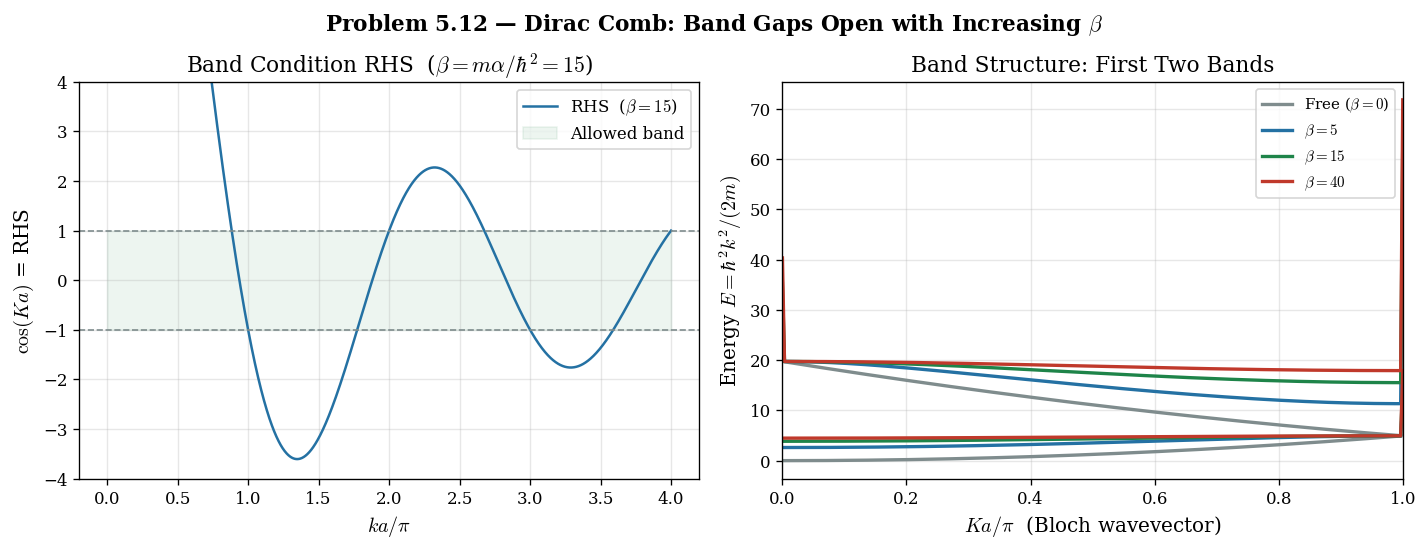

In [4]:
# Figure 5.12: Dirac comb band structure
# Units: hbar=1, m=1, a=1; beta = m*alpha/hbar^2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

k_arr = np.linspace(1e-4, 4*np.pi, 2000)
beta_vals = [0, 5, 15, 40]
col_b     = [GRAY, BLUE, GREEN, RED]

# Left: RHS of band condition (beta=15)
ax   = axes[0]
beta = 15.0
rhs  = np.cos(k_arr) + (beta/k_arr)*np.sin(k_arr)
ax.plot(k_arr/np.pi, rhs, color=BLUE, lw=1.5, label=r'RHS  ($\beta=15$)')
ax.axhline( 1, color=GRAY, ls='--', lw=1)
ax.axhline(-1, color=GRAY, ls='--', lw=1)
ax.fill_between(k_arr/np.pi, -1, 1, alpha=0.08, color=GREEN, label='Allowed band')
ax.set_xlabel(r'$ka/\pi$')
ax.set_ylabel(r'$\cos(Ka)$ = RHS')
ax.set_title(r'Band Condition RHS  ($\beta = m\alpha/\hbar^2 = 15$)')
ax.set_ylim(-4, 4); ax.legend(); ax.grid(True, alpha=0.3)

# Right: E(K) band structure
ax2  = axes[1]
K_BZ = np.linspace(0, np.pi, 300)

for beta, c in zip(beta_vals, col_b):
    E_bands = []
    for K in K_BZ:
        target = np.cos(K)
        E_list = []
        for band in range(6):
            k_lo = band*np.pi + 1e-6
            k_hi = (band+1)*np.pi - 1e-6
            f_lo = np.cos(k_lo) + (beta/k_lo)*np.sin(k_lo) - target
            f_hi = np.cos(k_hi) + (beta/k_hi)*np.sin(k_hi) - target
            if f_lo * f_hi < 0:
                try:
                    k_sol = brentq(lambda k: np.cos(k)+(beta/k)*np.sin(k)-target,
                                   k_lo, k_hi)
                    E_list.append(k_sol**2 / 2)
                except Exception:
                    pass
        E_bands.append(E_list[:2])

    E1  = [e[0] if len(e)>0 else np.nan for e in E_bands]
    E2  = [e[1] if len(e)>1 else np.nan for e in E_bands]
    lbl = fr'$\beta={beta}$' if beta>0 else r'Free ($\beta=0$)'
    ax2.plot(K_BZ/np.pi, E1, color=c, lw=2, label=lbl)
    ax2.plot(K_BZ/np.pi, E2, color=c, lw=2)

ax2.set_xlabel(r'$Ka/\pi$  (Bloch wavevector)')
ax2.set_ylabel(r'Energy $E = \hbar^2k^2/(2m)$')
ax2.set_title('Band Structure: First Two Bands')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_xlim(0, 1)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle(r'Problem 5.12 — Dirac Comb: Band Gaps Open with Increasing $\beta$',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_12.png')); plt.show()


---
## Problem 5.15 — Planck Distribution: Blackbody Radiation {#prob_5_15}

$u(\omega) = \dfrac{\hbar\omega^3}{\pi^2 c^3}\dfrac{1}{e^{\hbar\omega/k_BT}-1}$


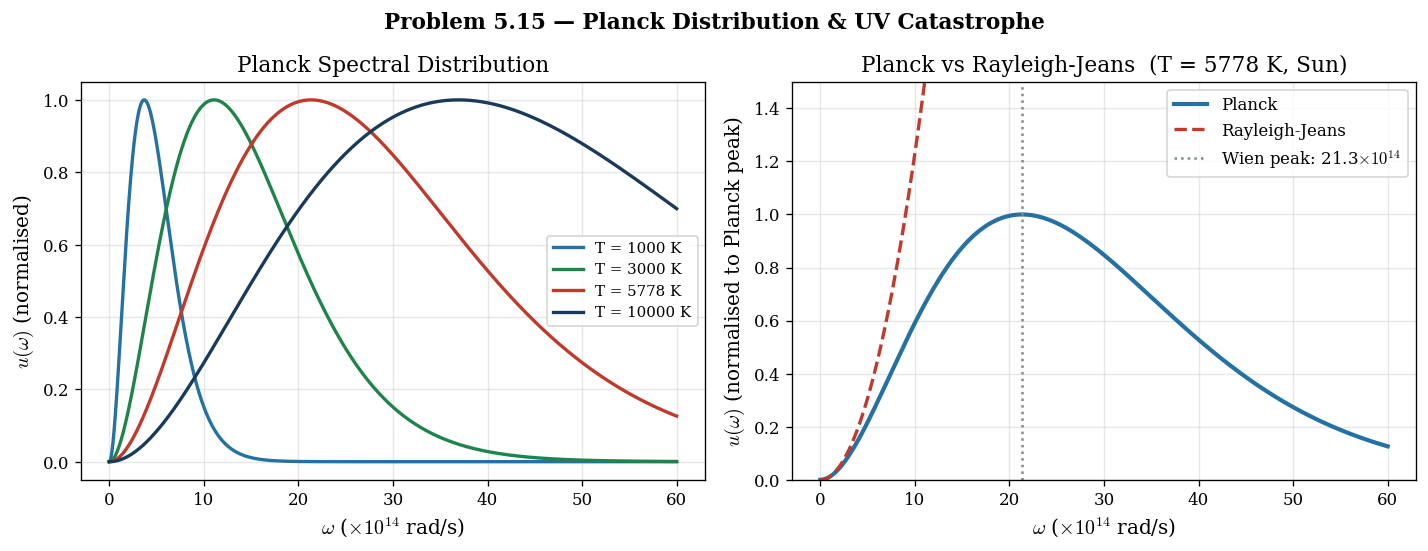

In [5]:
# --- Figure 5.15: Planck distribution vs Rayleigh-Jeans ---
# FIX: omega range extended to 6e15 to cover Wien peaks of all T values
hbar = 1.055e-34; kB = 1.381e-23; c = 3e8

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

omega  = np.linspace(1e11, 6e15, 3000)
T_vals = [1000, 3000, 5778, 10000]
col_T  = [BLUE, GREEN, RED, NAVY]

ax = axes[0]
for T, col in zip(T_vals, col_T):
    u = (hbar*omega**3)/(np.pi**2*c**3) / (np.exp(hbar*omega/(kB*T)) - 1)
    ax.plot(omega/1e14, u/u.max(), color=col, lw=2, label=f'T = {T} K')
ax.set_xlabel(r'$\omega$ ($\times 10^{14}$ rad/s)')
ax.set_ylabel(r'$u(\omega)$ (normalised)')
ax.set_title('Planck Spectral Distribution')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2  = axes[1]
T    = 5778.0
u_P  = (hbar*omega**3)/(np.pi**2*c**3) / (np.exp(hbar*omega/(kB*T)) - 1)
u_RJ = (omega**2 * kB*T) / (np.pi**2 * c**3)
ax2.plot(omega/1e14, u_P/u_P.max(),  color=BLUE, lw=2.5, label='Planck')
ax2.plot(omega/1e14, u_RJ/u_P.max(), color=RED,  lw=2,   ls='--', label='Rayleigh-Jeans')
omega_peak = 2.821*kB*T/hbar
ax2.axvline(omega_peak/1e14, color=GRAY, ls=':', lw=1.5,
            label=f'Wien peak: {omega_peak/1e14:.1f}'+r'$\times10^{14}$')
ax2.set_ylim(0, 1.5)
ax2.set_xlabel(r'$\omega$ ($\times 10^{14}$ rad/s)')
ax2.set_ylabel(r'$u(\omega)$ (normalised to Planck peak)')
ax2.set_title(f'Planck vs Rayleigh-Jeans  (T = {T:.0f} K, Sun)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 5.15 — Planck Distribution & UV Catastrophe',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_15.png')); plt.show()


---
## Problem 5.16 — Bose-Einstein Condensation {#prob_5_16}

$T_c = \dfrac{2\pi\hbar^2}{mk_B}\!\left(\dfrac{N}{2.612\,V}\right)^{2/3}$,  
$N_0/N = 1-(T/T_c)^{3/2}$ for $T < T_c$


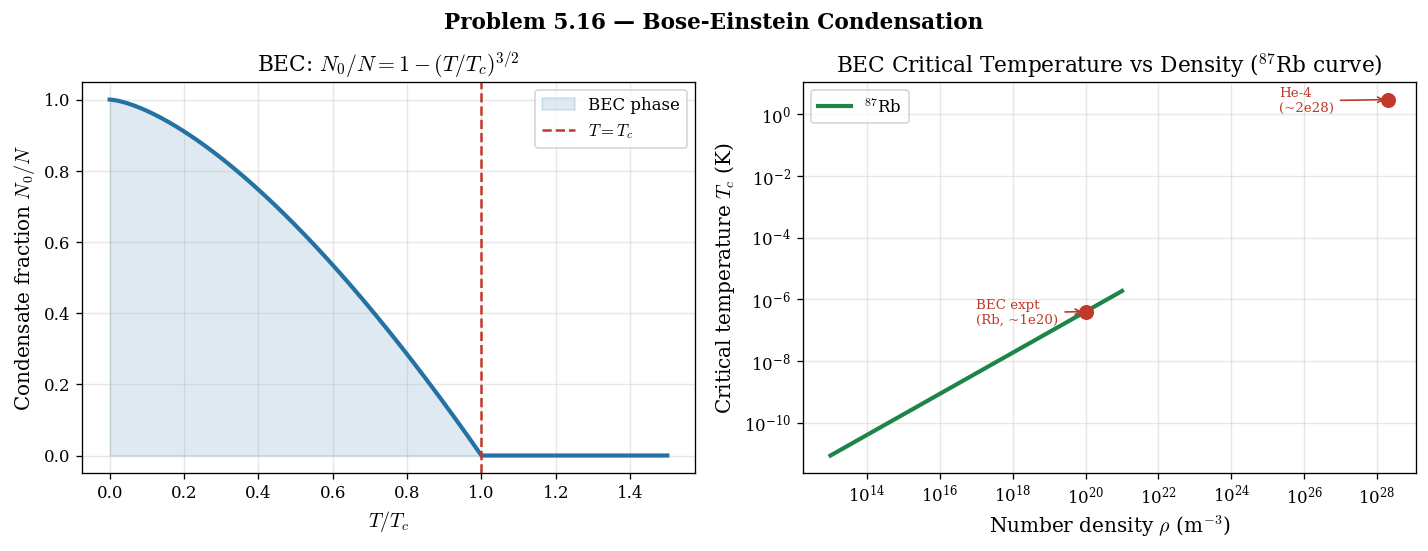

In [6]:
# --- Figure 5.16: BEC condensate fraction and critical temperature ---
# FIX: He-4 annotation now uses m_He4 = 4*1.66e-27 (was incorrectly using m_Rb)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: condensate fraction
ax    = axes[0]
t_arr = np.linspace(0, 1.5, 400)
N0_N  = np.where(t_arr < 1, 1 - t_arr**1.5, 0.0)
ax.plot(t_arr, N0_N, color=BLUE, lw=2.5)
ax.fill_between(t_arr, N0_N, where=t_arr<1, alpha=0.15, color=BLUE, label='BEC phase')
ax.axvline(1.0, color=RED, ls='--', lw=1.5, label=r'$T = T_c$')
ax.set_xlabel(r'$T/T_c$')
ax.set_ylabel(r'Condensate fraction $N_0/N$')
ax.set_title(r'BEC: $N_0/N = 1-(T/T_c)^{3/2}$')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: Tc vs density for 87Rb
ax2     = axes[1]
hbar    = 1.055e-34; kB = 1.381e-23; m_Rb = 87*1.66e-27
rho_arr = np.logspace(13, 21, 300)
Tc_arr  = (2*np.pi*hbar**2/(m_Rb*kB)) * (rho_arr/2.612)**(2/3)
ax2.loglog(rho_arr, Tc_arr, color=GREEN, lw=2.5, label=r'$^{87}$Rb')

# FIX: use correct mass for each species
exp_pts = [
    ('BEC expt\n(Rb, ~1e20)', 1e20, m_Rb),
    ('He-4\n(~2e28)',          2e28, 4*1.66e-27),
]
for name, rho, mass in exp_pts:
    Tc = (2*np.pi*hbar**2/(mass*kB)) * (rho/2.612)**(2/3)
    ax2.plot(rho, Tc, 'o', color=RED, ms=8)
    ax2.annotate(name, xy=(rho, Tc), xytext=(rho*1e-3, Tc*0.4),
                 fontsize=8, color=RED,
                 arrowprops=dict(arrowstyle='->', color=RED))

ax2.set_xlabel(r'Number density $\rho$ (m$^{-3}$)')
ax2.set_ylabel(r'Critical temperature $T_c$ (K)')
ax2.set_title(r'BEC Critical Temperature vs Density ($^{87}$Rb curve)')
ax2.legend(); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 5.16 — Bose-Einstein Condensation',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_16.png')); plt.show()


---
## Problem 5.20 — Sommerfeld Expansion: Electronic Heat Capacity {#prob_5_20}

$C_V = \dfrac{\pi^2}{2}Nk_B\dfrac{k_BT}{E_F} = \gamma T$,  
$\gamma = \dfrac{\pi^2 Nk_B^2}{2E_F}$


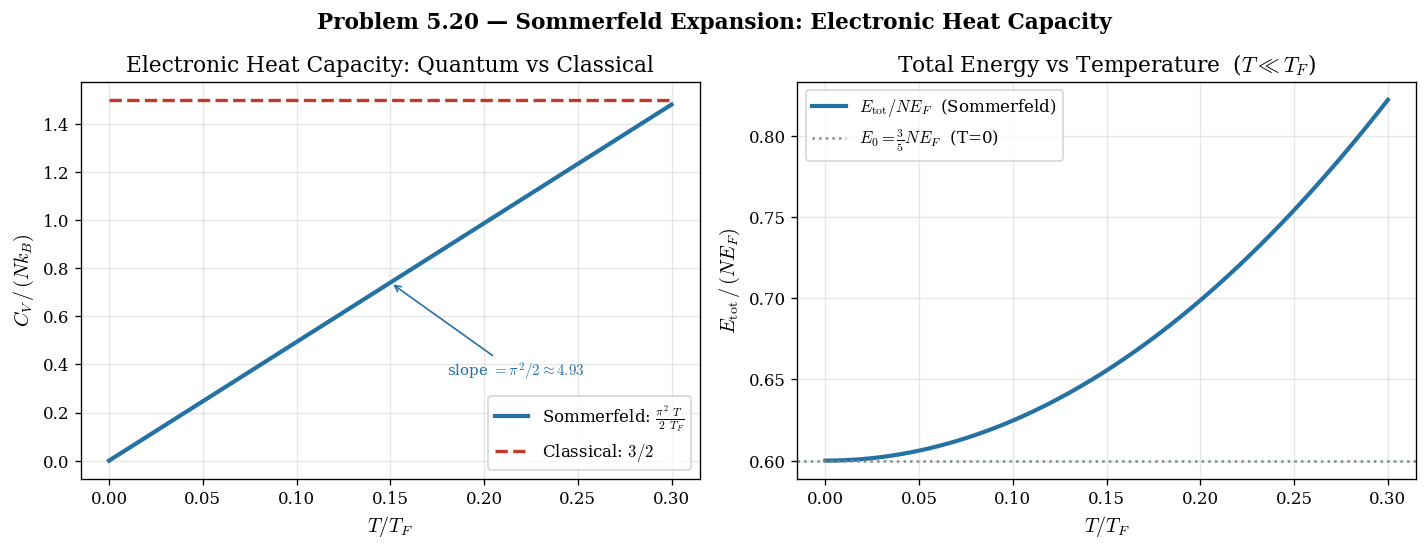

Sommerfeld slope pi^2/2 = 4.9348
Classical value 3/2 = 1.5000
Ratio at T/TF=0.01: 0.0329  (quantum << classical)


In [7]:
# Figure 5.20: Electronic heat capacity — Sommerfeld vs classical
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

t_arr         = np.linspace(0, 0.3, 300)   # T/T_F
Cv_sommerfeld = (np.pi**2/2) * t_arr        # units of N*kB
Cv_classical  = 1.5 * np.ones_like(t_arr)  # 3/2 NkB

ax = axes[0]
ax.plot(t_arr, Cv_sommerfeld, color=BLUE, lw=2.5,
        label=r'Sommerfeld: $\frac{\pi^2}{2}\frac{T}{T_F}$')
ax.plot(t_arr, Cv_classical,  color=RED,  lw=2, ls='--',
        label='Classical: $3/2$')
slope = np.pi**2/2
ax.annotate(fr'slope $= \pi^2/2 \approx {slope:.2f}$',
            xy=(0.15, slope*0.15), xytext=(0.18, 0.35),
            fontsize=9, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE))
ax.set_xlabel(r'$T/T_F$')
ax.set_ylabel(r'$C_V\,/\,(Nk_B)$')
ax.set_title('Electronic Heat Capacity: Quantum vs Classical')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
E0  = 3/5
E_T = E0 * (1 + (5*np.pi**2/12)*t_arr**2)
ax2.plot(t_arr, E_T, color=BLUE, lw=2.5, label=r'$E_{\rm tot}/NE_F$  (Sommerfeld)')
ax2.axhline(E0, color=GRAY, ls=':', lw=1.5, label=r'$E_0 = \frac{3}{5}NE_F$  (T=0)')
ax2.set_xlabel(r'$T/T_F$')
ax2.set_ylabel(r'$E_{\rm tot}\,/\,(NE_F)$')
ax2.set_title(r'Total Energy vs Temperature  ($T\ll T_F$)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 5.20 — Sommerfeld Expansion: Electronic Heat Capacity',
             fontsize=13, fontweight='bold', y=1.01)
figures.append((fig, 'fig_5_20.png')); plt.show()
print(f'Sommerfeld slope pi^2/2 = {np.pi**2/2:.4f}')
print(f'Classical value 3/2 = 1.5000')
print(f'Ratio at T/TF=0.01: {(np.pi**2/2)*0.01/1.5:.4f}  (quantum << classical)')


---
## Save All Figures & Download as ZIP


In [8]:
import os, zipfile
save_dir = 'ch05_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch05_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch05_figures/fig_5_5.png
Saved: ch05_figures/fig_5_9_11.png
Saved: ch05_figures/fig_5_12.png
Saved: ch05_figures/fig_5_15.png
Saved: ch05_figures/fig_5_16.png
Saved: ch05_figures/fig_5_20.png
Zip: ch05_figures.zip,  Files: ['fig_5_5.png', 'fig_5_9_11.png', 'fig_5_12.png', 'fig_5_15.png', 'fig_5_16.png', 'fig_5_20.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
